RESUMEN ESTADÍSTICO

Método 1 IQ
--------------------------------------------------------------------------------
Piso de ruido   -> media= -68.434 dBm | std=   0.378
Potencia central-> media= -53.596 dBm | std=   1.028
SNR central     -> media=  14.837 dB  | std=   0.865

Método 2 IQ
--------------------------------------------------------------------------------
Piso de ruido   -> media= -69.458 dBm | std=   0.663
Potencia central-> media= -54.987 dBm | std=   1.520
SNR central     -> media=  14.470 dB  | std=   1.090

Método 3 IQ
--------------------------------------------------------------------------------
Piso de ruido   -> media= -70.045 dBm | std=   0.659
Potencia central-> media=-103.037 dBm | std=   2.864
SNR central     -> media= -32.992 dB  | std=   2.554


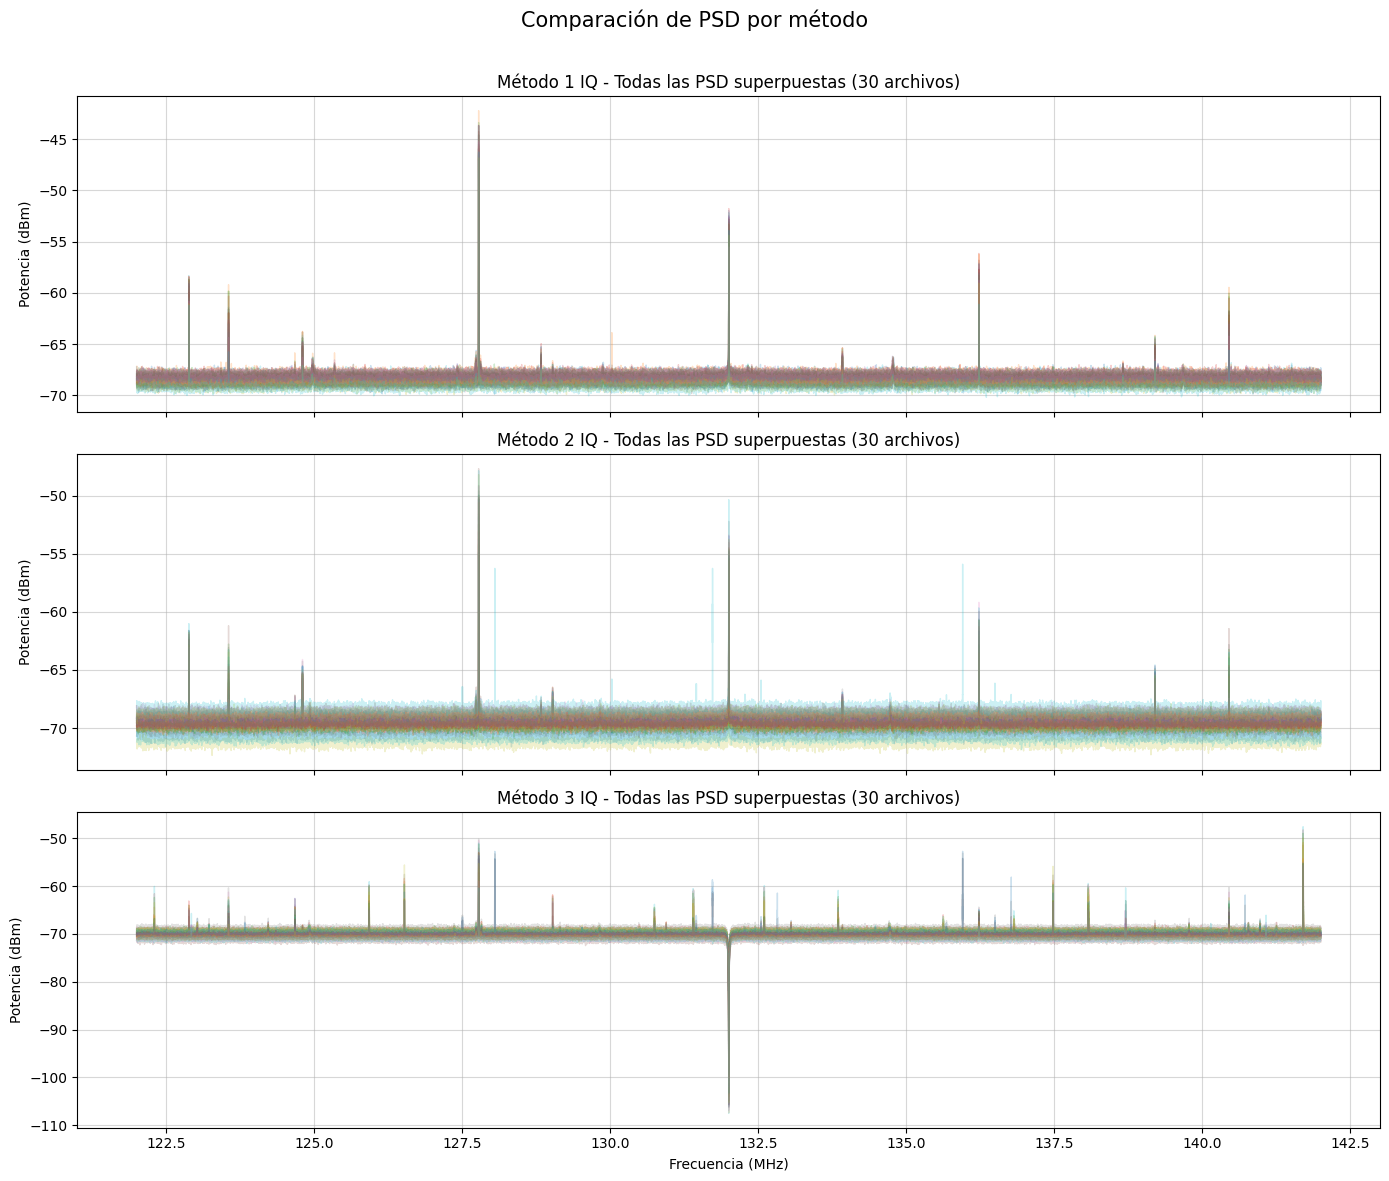

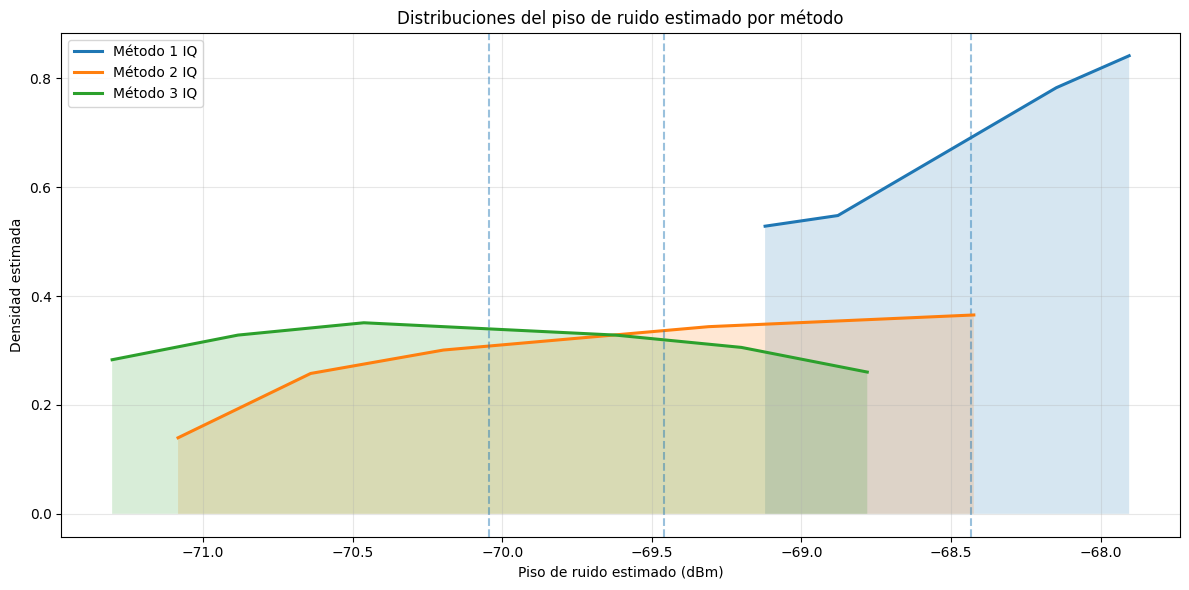

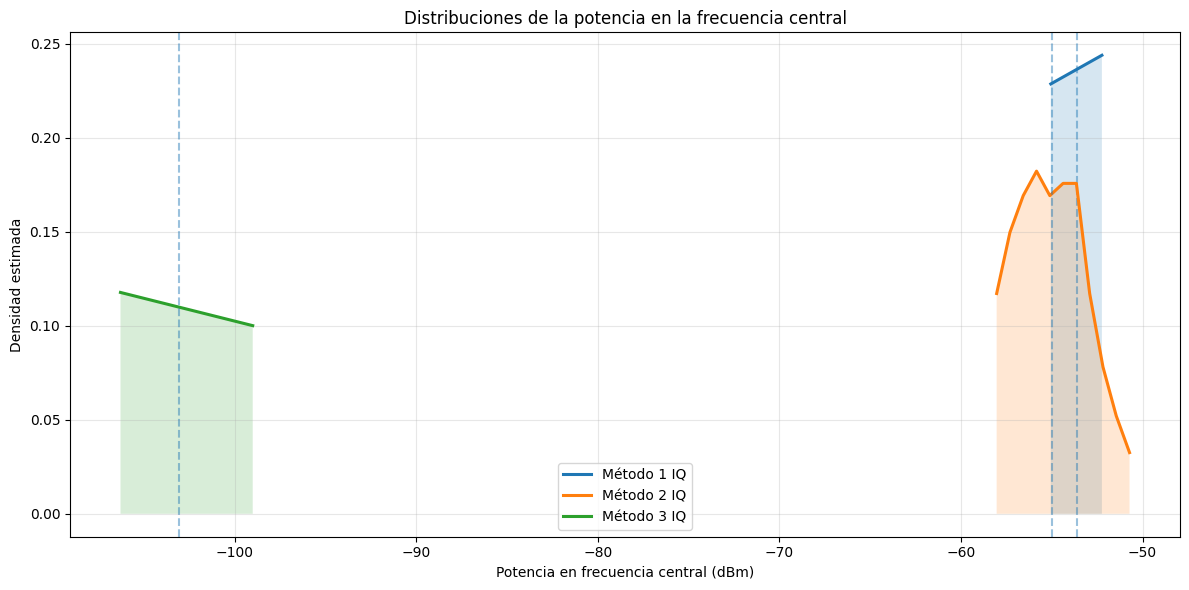

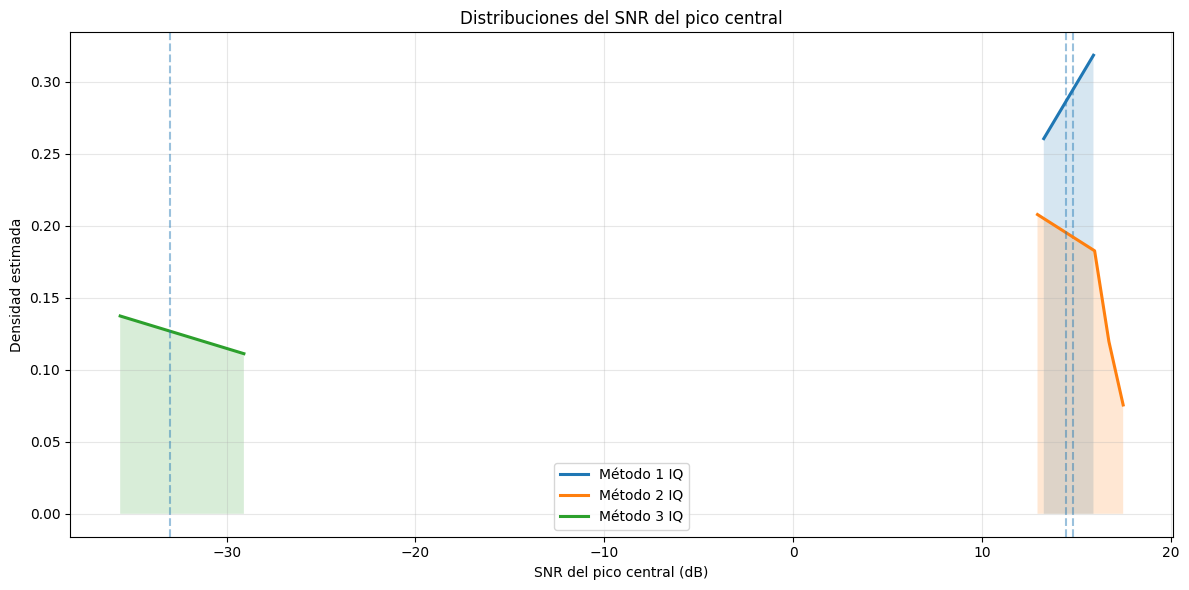

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

# ============================================================
# 1) CONFIGURACIÓN
# ============================================================

folders = {
    "Método 1 IQ": "metodo_1_iq",
    "Método 2 IQ": "metodo_2_iq",
    "Método 3 IQ": "metodo_3_iq",
}

N_FILES = 30  # número máximo de CSV por carpeta

# Colores fijos por método
method_colors = {
    "Método 1 IQ": "#1f77b4",  # azul
    "Método 2 IQ": "#ff7f0e",  # naranja
    "Método 3 IQ": "#2ca02c",  # verde
}

# Parámetros gráficos
PSD_ALPHA = 0.18
PSD_LINEWIDTH = 1.0
DIST_LINEWIDTH = 2.4
DIST_FILL_ALPHA = 0.18

# KDE
# bw_method puede ser:
#   - 'scott'
#   - 'silverman'
#   - float (ej. 0.25, 0.35, 0.5)
KDE_BW_METHOD = "scott"

# Resolución de la grilla para las PDFs
KDE_GRID_POINTS = 500

# Extensión del soporte para que no se "recorte" visualmente
# Se expande a ambos lados del rango observado
KDE_MARGIN_FACTOR = 0.20


# ============================================================
# 2) LECTURA DE CSV PSD
# ============================================================

def load_psd_csv(filepath):
    """
    Lee un CSV con metadatos al inicio y luego columnas:
    Frecuencia (Hz),Potencia (dBm)

    Retorna
    -------
    freq_hz : np.ndarray
    power_dbm : np.ndarray
    """
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Frecuencia (Hz)" in line and "Potencia (dBm)" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No se encontró la cabecera de datos en: {filepath}")

    data_lines = lines[header_idx + 1:]

    freq = []
    power = []

    for line in data_lines:
        parts = line.strip().split(",")
        if len(parts) != 2:
            continue

        try:
            f_hz = float(parts[0])
            p_dbm = float(parts[1])
            freq.append(f_hz)
            power.append(p_dbm)
        except ValueError:
            continue

    if len(freq) == 0:
        raise ValueError(f"No se encontraron datos válidos en: {filepath}")

    return np.array(freq, dtype=float), np.array(power, dtype=float)


# ============================================================
# 3) MÉTRICAS SOBRE CADA PSD
# ============================================================

def get_center_frequency_power(freq_hz, power_dbm):
    """
    Obtiene la potencia en la frecuencia central del barrido.
    La frecuencia central se aproxima como el punto medio entre
    la frecuencia mínima y máxima del vector de frecuencias.
    """
    f_center = 0.5 * (freq_hz[0] + freq_hz[-1])
    idx_center = np.argmin(np.abs(freq_hz - f_center))

    return freq_hz[idx_center], power_dbm[idx_center], idx_center


def compute_psd_metrics(freq_hz, power_dbm):
    """
    Calcula métricas simples:
      - piso de ruido: media del vector de potencia
      - potencia en frecuencia central
      - SNR del pico central
    """
    noise_floor_dbm = np.mean(power_dbm)

    f_center_hz, p_center_dbm, idx_center = get_center_frequency_power(freq_hz, power_dbm)

    snr_center_db = p_center_dbm - noise_floor_dbm

    return {
        "noise_floor_dbm": noise_floor_dbm,
        "f_center_hz": f_center_hz,
        "p_center_dbm": p_center_dbm,
        "snr_center_db": snr_center_db,
        "idx_center": idx_center,
    }


# ============================================================
# 4) KDE
# ============================================================

def estimate_kde(samples, bw_method="scott", grid_points=500, margin_factor=0.20):
    """
    Estima una densidad usando Kernel Density Estimation (KDE).

    Parámetros
    ----------
    samples : array-like
        Muestras 1D.
    bw_method : str o float
        Método/ancho de banda para gaussian_kde.
    grid_points : int
        Número de puntos de la grilla.
    margin_factor : float
        Fracción del rango usada para extender el soporte.

    Retorna
    -------
    x_grid : np.ndarray
        Grilla donde se evalúa la KDE.
    density : np.ndarray
        Densidad estimada.
    """
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if len(samples) < 2:
        raise ValueError("Se requieren al menos 2 muestras para KDE.")

    xmin = np.min(samples)
    xmax = np.max(samples)
    xrng = xmax - xmin

    # Si todas las muestras son casi iguales, dar un pequeño soporte artificial
    if xrng < 1e-12:
        xrng = 1.0

    margin = margin_factor * xrng

    x_grid = np.linspace(xmin - margin, xmax + margin, grid_points)

    kde = gaussian_kde(samples, bw_method=bw_method)
    density = kde(x_grid)

    density = np.clip(density, 0, None)

    return x_grid, density


# ============================================================
# 5) CARGA DE DATOS Y EXTRACCIÓN DE MÉTRICAS
# ============================================================

all_psd = {}
all_metrics = {}

for label, folder in folders.items():
    csv_files = sorted(glob.glob(os.path.join(folder, "*.csv")))[:N_FILES]

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No se encontraron archivos CSV en la carpeta: {folder}")

    psd_list = []
    noise_floor_values = []
    center_power_values = []
    snr_values = []

    for filepath in csv_files:
        freq_hz, power_dbm = load_psd_csv(filepath)
        metrics = compute_psd_metrics(freq_hz, power_dbm)

        psd_list.append({
            "file": os.path.basename(filepath),
            "freq_hz": freq_hz,
            "power_dbm": power_dbm,
            "metrics": metrics
        })

        noise_floor_values.append(metrics["noise_floor_dbm"])
        center_power_values.append(metrics["p_center_dbm"])
        snr_values.append(metrics["snr_center_db"])

    all_psd[label] = psd_list
    all_metrics[label] = {
        "noise_floor_dbm": np.array(noise_floor_values, dtype=float),
        "center_power_dbm": np.array(center_power_values, dtype=float),
        "snr_center_db": np.array(snr_values, dtype=float),
    }


# ============================================================
# 6) FIGURA 1: TODAS LAS PSD SUPERPUESTAS POR MÉTODO
# ============================================================

fig_psd, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (label, psd_list) in zip(axes, all_psd.items()):
    color = method_colors.get(label, None)

    for item in psd_list:
        freq_mhz = item["freq_hz"] / 1e6
        power_dbm = item["power_dbm"]
        ax.plot(
            freq_mhz,
            power_dbm,
            color=color,
            alpha=PSD_ALPHA,
            linewidth=PSD_LINEWIDTH
        )

    # Marcar frecuencia central promedio visualmente
    freq_ref = psd_list[0]["freq_hz"] / 1e6
    f_center_mhz = 0.5 * (freq_ref[0] + freq_ref[-1])
    ax.axvline(f_center_mhz, color=color, linestyle="--", alpha=0.6)

    ax.set_title(f"{label} - PSD superpuestas ({len(psd_list)} archivos)")
    ax.set_ylabel("Potencia (dBm)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Frecuencia (MHz)")
fig_psd.suptitle("Comparación de PSD por método", fontsize=15)
fig_psd.tight_layout(rect=[0, 0, 1, 0.97])


# ============================================================
# 7) FUNCIÓN PARA PLOTEAR DISTRIBUCIONES KDE
# ============================================================

def plot_compared_kde(metric_dict, title, xlabel,
                      bw_method="scott",
                      grid_points=500,
                      margin_factor=0.20,
                      colors=None):
    """
    Plotea KDE comparada de varias métricas.

    metric_dict:
        {
            "Método 1 IQ": np.array(...),
            "Método 2 IQ": np.array(...),
            ...
        }
    """
    plt.figure(figsize=(12, 6))

    global_min = min(np.min(v[np.isfinite(v)]) for v in metric_dict.values())
    global_max = max(np.max(v[np.isfinite(v)]) for v in metric_dict.values())
    global_range = global_max - global_min
    if global_range < 1e-12:
        global_range = 1.0
    x_margin = margin_factor * global_range

    for label, values in metric_dict.items():
        color = colors.get(label, None) if colors else None

        x_grid, density = estimate_kde(
            values,
            bw_method=bw_method,
            grid_points=grid_points,
            margin_factor=margin_factor
        )

        plt.plot(
            x_grid, density,
            linewidth=DIST_LINEWIDTH,
            color=color,
            label=label
        )

        plt.fill_between(
            x_grid, density,
            alpha=DIST_FILL_ALPHA,
            color=color
        )

        # línea vertical en la media
        mean_val = np.mean(values)
        plt.axvline(
            mean_val,
            linestyle="--",
            linewidth=1.7,
            alpha=0.45,
            color=color
        )

    plt.xlim(global_min - x_margin, global_max + x_margin)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Densidad estimada (KDE)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


# ============================================================
# 8) FIGURA 2: DISTRIBUCIONES DEL PISO DE RUIDO
# ============================================================

noise_floor_dict = {
    label: metrics["noise_floor_dbm"]
    for label, metrics in all_metrics.items()
}

plot_compared_kde(
    noise_floor_dict,
    title="Distribuciones KDE del piso de ruido estimado por método",
    xlabel="Piso de ruido estimado (dBm)",
    bw_method=KDE_BW_METHOD,
    grid_points=KDE_GRID_POINTS,
    margin_factor=KDE_MARGIN_FACTOR,
    colors=method_colors
)


# ============================================================
# 9) FIGURA 3: DISTRIBUCIONES DE LA POTENCIA EN LA FRECUENCIA CENTRAL
# ============================================================

center_power_dict = {
    label: metrics["center_power_dbm"]
    for label, metrics in all_metrics.items()
}

plot_compared_kde(
    center_power_dict,
    title="Distribuciones KDE de la potencia en la frecuencia central",
    xlabel="Potencia en frecuencia central (dBm)",
    bw_method=KDE_BW_METHOD,
    grid_points=KDE_GRID_POINTS,
    margin_factor=KDE_MARGIN_FACTOR,
    colors=method_colors
)


# ============================================================
# 10) FIGURA 4: DISTRIBUCIONES DEL SNR DEL PICO CENTRAL
# ============================================================

snr_dict = {
    label: metrics["snr_center_db"]
    for label, metrics in all_metrics.items()
}

plot_compared_kde(
    snr_dict,
    title="Distribuciones KDE del SNR del pico central",
    xlabel="SNR del pico central (dB)",
    bw_method=KDE_BW_METHOD,
    grid_points=KDE_GRID_POINTS,
    margin_factor=KDE_MARGIN_FACTOR,
    colors=method_colors
)


# ============================================================
# 11) RESUMEN NUMÉRICO
# ============================================================

print("=" * 90)
print("RESUMEN ESTADÍSTICO")
print("=" * 90)

for label, metrics in all_metrics.items():
    nf = metrics["noise_floor_dbm"]
    cp = metrics["center_power_dbm"]
    snr = metrics["snr_center_db"]

    print(f"\n{label}")
    print("-" * 90)
    print(f"Piso de ruido    -> media = {np.mean(nf):8.3f} dBm | std = {np.std(nf, ddof=1):8.3f}")
    print(f"Potencia central -> media = {np.mean(cp):8.3f} dBm | std = {np.std(cp, ddof=1):8.3f}")
    print(f"SNR central      -> media = {np.mean(snr):8.3f} dB  | std = {np.std(snr, ddof=1):8.3f}")


# ============================================================
# 12) MOSTRAR FIGURAS
# ============================================================

plt.show()